In [1]:
# ============================================================
# PFE Baseline: ResNet-50 on CIFAR-10 (PyTorch)
# Fixed: architecture adapted for 32x32, consistent preprocessing
# Ready for: Pruning, Quantization, Distillation, LoRA
# ============================================================

import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
import time, os, json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (confusion_matrix, classification_report,
                             accuracy_score, precision_score,
                             recall_score, f1_score)
from thop import profile
from PIL import Image

In [ ]:
# ── REPRODUCIBILITY ───────────────────────────────────────────
# Add this right after your imports, before anything else

SEED = 42

import random
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)                        # if using multi-GPU

# Force cuDNN to use deterministic algorithms
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False              # disable auto-tuner

# Make DataLoaders reproducible
def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

g = torch.Generator()
g.manual_seed(SEED)

In [ ]:
# ── CONFIG ───────────────────────────────────────────────────
DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE  = 128
EPOCHS      = 50
LR          = 1e-3
NUM_CLASSES = 10
SAVE_PATH   = "__2__baseline_resnet50_cifar10.pth"

CIFAR10_CLASSES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
                   'dog', 'frog', 'horse', 'ship', 'truck']

# These MUST be used consistently everywhere: training, evaluation, prediction
CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD  = (0.2023, 0.1994, 0.2010)

print(f"Using device: {DEVICE}")

Using device: cuda


In [ ]:
# ── MODEL: ResNet-50 adapted for 32x32 images ─────────────────
# Problem: original ResNet-50 first conv is 7x7 stride 2 + maxpool
# On 32x32 this kills spatial info immediately → poor accuracy
# Fix: replace with 3x3 stride 1, remove maxpool → same as CIFAR ResNet papers
def build_model(num_classes=10):
    model = models.resnet50(pretrained=True)

    # Replace first conv: 7x7 stride 2 → 3x3 stride 1 (no spatial downsampling)
    model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)

    # Remove maxpool (would halve 32→16 immediately, too aggressive)
    model.maxpool = nn.Identity()

    # Replace classifier head
    model.fc = nn.Linear(model.fc.in_features, num_classes)

    return model

model = build_model(NUM_CLASSES).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")

Total parameters: 23,520,842


In [ ]:
# ── DATA ─────────────────────────────────────────────────────
# No resize needed — keep native 32x32, architecture handles it correctly now
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD)
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD)   # same normalization, no augmentation
])

train_set = torchvision.datasets.CIFAR10(root='./data', train=True,
                                          download=True, transform=transform_train)
test_set  = torchvision.datasets.CIFAR10(root='./data', train=False,
                                          download=True, transform=transform_test)

train_loader = torch.utils.data.DataLoader(train_set, batch_size=BATCH_SIZE,
                                            shuffle=True, num_workers=0,
                                            worker_init_fn=seed_worker,
                                            generator=g)
test_loader  = torch.utils.data.DataLoader(test_set,  batch_size=BATCH_SIZE,
                                            shuffle=False, num_workers=0,
                                            worker_init_fn=seed_worker)

print(f"Train: {len(train_set)} | Test: {len(test_set)}")

Train: 50000 | Test: 10000


In [ ]:
# ── TRAINING ──────────────────────────────────────────────────
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.SGD(model.parameters(), lr=0.1,
                             momentum=0.9, weight_decay=5e-4)  # SGD beats Adam on CIFAR
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for inputs, labels in loader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct += outputs.argmax(1).eq(labels).sum().item()
        total   += labels.size(0)
    return total_loss / len(loader), correct / total

def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            correct += model(inputs).argmax(1).eq(labels).sum().item()
            total   += labels.size(0)
    return correct / total

best_val_acc = 0.0
train_accs, val_accs, train_losses = [], [], []

print("\n" + "="*55)
print("TRAINING")
print("="*55)

for epoch in range(EPOCHS):
    loss, train_acc = train_epoch(model, train_loader, optimizer, criterion)
    val_acc = evaluate(model, test_loader)
    scheduler.step()

    train_accs.append(train_acc)
    val_accs.append(val_acc)
    train_losses.append(loss)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), SAVE_PATH)
        marker = " ← best saved"
    else:
        marker = ""

    print(f"Epoch {epoch+1:2d}/{EPOCHS} | Loss: {loss:.4f} | "
          f"Train: {train_acc:.4f} | Val: {val_acc:.4f}{marker}")

print(f"\nBest validation accuracy: {best_val_acc:.4f} ({best_val_acc*100:.2f}%)")


TRAINING
Epoch  1/50 | Loss: 2.3034 | Train: 0.2141 | Val: 0.2928 ← best saved
Epoch  2/50 | Loss: 1.9289 | Train: 0.3212 | Val: 0.3672 ← best saved
Epoch  3/50 | Loss: 1.8109 | Train: 0.3832 | Val: 0.3879 ← best saved
Epoch  4/50 | Loss: 1.7081 | Train: 0.4382 | Val: 0.4767 ← best saved
Epoch  5/50 | Loss: 1.5900 | Train: 0.4972 | Val: 0.4918 ← best saved
Epoch  6/50 | Loss: 1.4330 | Train: 0.5752 | Val: 0.6023 ← best saved
Epoch  7/50 | Loss: 1.3160 | Train: 0.6333 | Val: 0.6190 ← best saved
Epoch  8/50 | Loss: 1.2439 | Train: 0.6696 | Val: 0.6421 ← best saved
Epoch  9/50 | Loss: 1.1868 | Train: 0.6930 | Val: 0.6742 ← best saved
Epoch 10/50 | Loss: 1.1471 | Train: 0.7140 | Val: 0.6916 ← best saved
Epoch 11/50 | Loss: 1.1148 | Train: 0.7279 | Val: 0.6929 ← best saved
Epoch 12/50 | Loss: 1.0810 | Train: 0.7422 | Val: 0.6920
Epoch 13/50 | Loss: 1.0443 | Train: 0.7602 | Val: 0.7243 ← best saved
Epoch 14/50 | Loss: 1.0012 | Train: 0.7813 | Val: 0.7614 ← best saved
Epoch 15/50 | Loss: 0.9

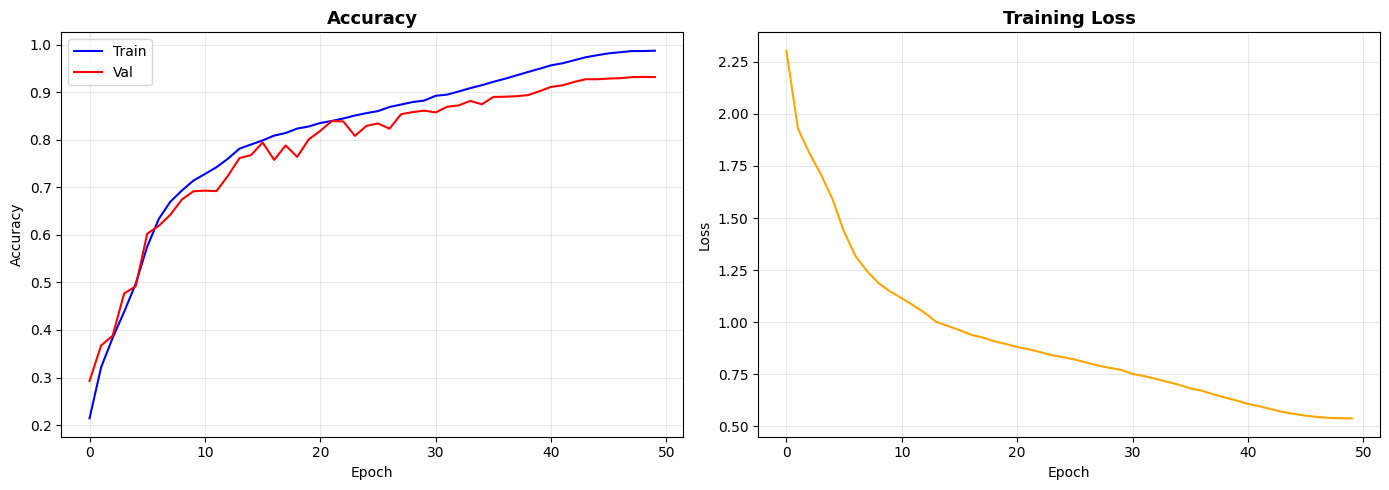

In [ ]:
# ── TRAINING CURVES ───────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(train_accs, label='Train', color='blue')
ax1.plot(val_accs,   label='Val',   color='red')
ax1.set_title('Accuracy', fontsize=13, fontweight='bold')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(train_losses, color='orange')
ax2.set_title('Training Loss', fontsize=13, fontweight='bold')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('__2__training_curves.png', dpi=150)
plt.show()

In [ ]:
# ── FULL EVALUATION ───────────────────────────────────────────
print("\n" + "="*55)
print("FULL EVALUATION")
print("="*55)

model.load_state_dict(torch.load(SAVE_PATH, map_location=DEVICE))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(DEVICE)
        preds  = model(inputs).argmax(1).cpu()
        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

acc       = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average='macro')
recall    = recall_score(all_labels, all_preds, average='macro')
f1        = f1_score(all_labels, all_preds, average='macro')

print(f"\n  Accuracy          : {acc:.4f}  ({acc*100:.2f}%)")
print(f"  Precision (macro) : {precision:.4f}")
print(f"  Recall    (macro) : {recall:.4f}")
print(f"  F1-score  (macro) : {f1:.4f}")
print("\nPer-class report:")
print(classification_report(all_labels, all_preds,
                             target_names=CIFAR10_CLASSES, digits=4))


FULL EVALUATION

  Accuracy          : 0.9320  (93.20%)
  Precision (macro) : 0.9319
  Recall    (macro) : 0.9320
  F1-score  (macro) : 0.9319

Per-class report:
              precision    recall  f1-score   support

    airplane     0.9373    0.9570    0.9471      1000
  automobile     0.9634    0.9730    0.9682      1000
        bird     0.9157    0.9130    0.9144      1000
         cat     0.8580    0.8520    0.8550      1000
        deer     0.9223    0.9380    0.9301      1000
         dog     0.8970    0.8710    0.8838      1000
        frog     0.9437    0.9560    0.9498      1000
       horse     0.9547    0.9490    0.9519      1000
        ship     0.9668    0.9610    0.9639      1000
       truck     0.9596    0.9500    0.9548      1000

    accuracy                         0.9320     10000
   macro avg     0.9319    0.9320    0.9319     10000
weighted avg     0.9319    0.9320    0.9319     10000



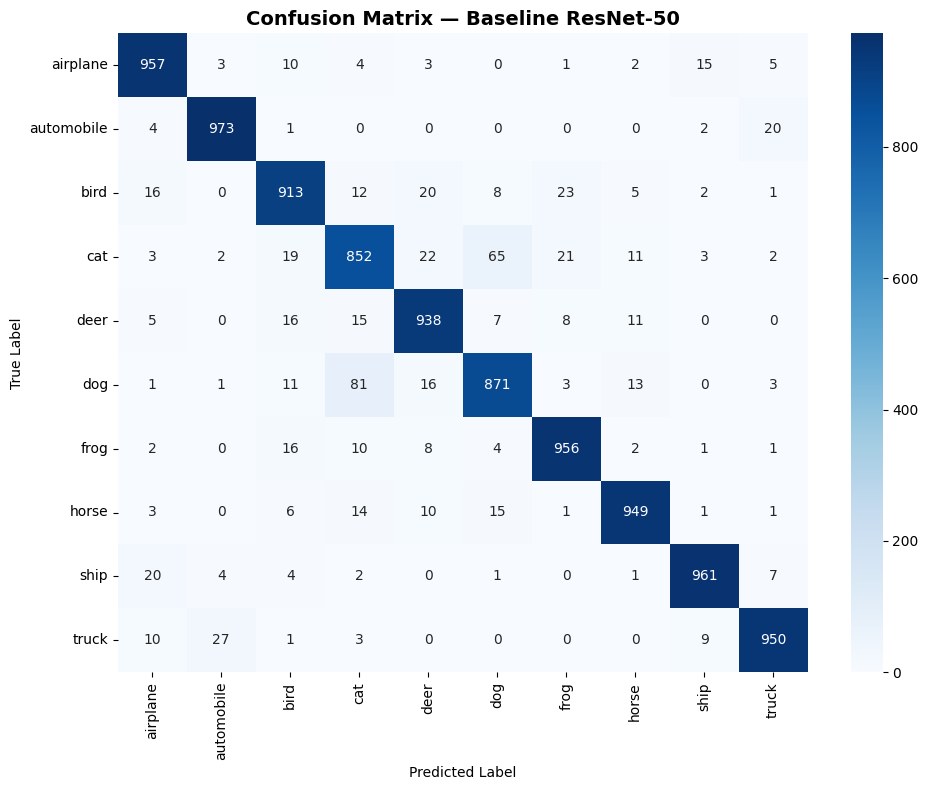

In [ ]:
# ── CONFUSION MATRIX ──────────────────────────────────────────
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CIFAR10_CLASSES, yticklabels=CIFAR10_CLASSES)
plt.title('Confusion Matrix — Baseline ResNet-50', fontsize=14, fontweight='bold')
plt.ylabel('True Label'); plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('__2__confusion_matrix.png', dpi=150)
plt.show()

In [ ]:
# ── MODEL COMPLEXITY METRICS ──────────────────────────────────
print("\n" + "="*55)
print("MODEL COMPLEXITY METRICS")
print("="*55)

size_mb = os.path.getsize(SAVE_PATH) / 1e6
dummy   = torch.randn(1, 3, 32, 32).to(DEVICE)
macs, _ = profile(model, inputs=(dummy,), verbose=False)
flops = macs * 2   

model.eval()
with torch.no_grad():
    for _ in range(10):     # warm-up
        model(dummy)
    times = []
    for _ in range(500):
        t0 = time.time()
        model(dummy)
        times.append(time.time() - t0)
inf_ms = np.mean(times) * 1000

print(f"  Parameters      : {total_params:,}")
print(f"  Model size      : {size_mb:.2f} MB")
print(f"  FLOPs           : {flops/1e9:.3f} GFLOPs")
print(f"  Inference time  : {inf_ms:.3f} ms")


MODEL COMPLEXITY METRICS
  Parameters      : 23,520,842
  Model size      : 94.41 MB
  FLOPs           : 1.312 GFLOPs
  Inference time  : 4.578 ms


In [ ]:
# ── SAVE METRICS JSON ─────────────────────────────────────────
baseline_metrics = {
    "accuracy"    : acc,
    "precision"   : precision,
    "recall"      : recall,
    "f1"          : f1,
    "params"      : total_params,
    "size_mb"     : size_mb,
    "flops_G"     : flops / 1e9,
    "inference_ms": inf_ms,
}
with open("__2__baseline_metrics.json", "w") as f:
    json.dump(baseline_metrics, f, indent=2)
print("\n✓ Metrics saved to baseline_metrics.json")


✓ Metrics saved to baseline_metrics.json


In [ ]:
import json
# ── PREDICT ON CUSTOM IMAGES ──────────────────────────────────
# Uses the EXACT same normalization as training — this is the key consistency rule

# Single transform used for ALL predictions — defined once, used everywhere
predict_transform = transforms.Compose([
    transforms.Resize((32, 32)),          # keep native CIFAR resolution
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD)   # same as training
])

def predict_image(image_path, model, show=True):
    img    = Image.open(image_path).convert('RGB')
    tensor = predict_transform(img).unsqueeze(0).to(DEVICE)

    model.eval()
    with torch.no_grad():
        probs = torch.softmax(model(tensor), dim=1).squeeze().cpu().numpy()

    pred_idx   = probs.argmax()
    pred_class = CIFAR10_CLASSES[pred_idx]
    confidence = probs[pred_idx]

    if show:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
        ax1.imshow(img)
        ax1.set_title(f"Prediction: {pred_class}\nConfidence: {confidence:.2%}",
                      fontsize=12, fontweight='bold')
        ax1.axis('off')

        colors = ['crimson' if i == pred_idx else 'steelblue' for i in range(NUM_CLASSES)]
        bars = ax2.barh(CIFAR10_CLASSES, probs, color=colors)
        ax2.set_xlabel('Probability')
        ax2.set_title('Class Probabilities')
        ax2.set_xlim(0, 1)
        for i, v in enumerate(probs):
            ax2.text(v + 0.01, i, f'{v:.1%}', va='center', fontsize=9)
        plt.tight_layout()
        plt.savefig(f'pred_{os.path.splitext(os.path.basename(image_path))[0]}.png', dpi=150)
        plt.show()

    top3 = sorted(zip(CIFAR10_CLASSES, probs), key=lambda x: -x[1])[:3]
    print(f"  File      : {os.path.basename(image_path)}")
    print(f"  Predicted : {pred_class} ({confidence:.2%})")
    print(f"  Top-3     : {[(c, f'{p:.2%}') for c, p in top3]}\n")
    return pred_class, probs


def predict_folder(folder_path, model,      save_json=True):
    supported = ('.jpg', '.jpeg', '.png', '.bmp', '.webp')
    files = [f for f in os.listdir(folder_path) if f.lower().endswith(supported)]
    if not files:
        print(f"No images found in {folder_path}")
        return
    print(f"\n{'File':<35} {'Prediction':<15} {'Confidence':>10}")
    print("-" * 62)
    results = []
    for fname in sorted(files):
        pred_class, probs = predict_image(os.path.join(folder_path, fname),
                                          model, show=False)
        # conf = probs.max()
        conf = float(probs.max())
        results.append((fname, pred_class, conf))
        print(f"  {fname:<33} {pred_class:<15} {conf:>9.2%}")
        print("────────────────────────────────────────────────────────────────────────────")
        
    # save JSON AFTER loop
    if save_json:
        with open("__2__output_on_test_data.json", "w") as f:
            json.dump(results, f, indent=4)

    return results


# ── USAGE ─────────────────────────────────────────────────────
# predict_image("./test_images/dog.jpg", model)
predict_folder("./data_test/", model)

print("\n" + "="*55)
print("BASELINE COMPLETE — ready for compression experiments")
print("="*55)
print(f"  Weights  → {SAVE_PATH}")
print(f"  Metrics  → baseline_metrics.json")
print(f"  Plots    → training_curves.png, confusion_matrix.png")
print(f"  Output   → output_on_test_data.json")


File                                Prediction      Confidence
--------------------------------------------------------------
  File      : airplane1.png
  Predicted : airplane (90.80%)
  Top-3     : [('airplane', '90.80%'), ('bird', '1.14%'), ('deer', '1.08%')]

  airplane1.png                     airplane           90.80%
────────────────────────────────────────────────────────────────────────────
  File      : airplane2.png
  Predicted : airplane (90.02%)
  Top-3     : [('airplane', '90.02%'), ('horse', '1.26%'), ('frog', '1.23%')]

  airplane2.png                     airplane           90.02%
────────────────────────────────────────────────────────────────────────────
  File      : airplane3.png
  Predicted : airplane (90.12%)
  Top-3     : [('airplane', '90.12%'), ('ship', '1.34%'), ('horse', '1.17%')]

  airplane3.png                     airplane           90.12%
────────────────────────────────────────────────────────────────────────────
  File      : airplane4.png
  Predicted 

In [ ]:
# saving the model with weights & classes names
config_dict = {
    "model_name": "resnet50_cifar10",
    "num_classes": NUM_CLASSES,
    "input_size": [3, 32, 32],

    "normalization": {
        "mean": CIFAR_MEAN,
        "std": CIFAR_STD
    },

    "training": {
        "batch_size": BATCH_SIZE,
        "epochs": EPOCHS,
        "learning_rate": LR,
        "optimizer": "SGD",
        "scheduler": "CosineAnnealingLR"
    }
}

class_names = CIFAR10_CLASSES


torch.save({
    "model_state_dict": model.state_dict(),
    "config": config_dict,
    "classes": class_names
}, "__2__model_checkpoint.pth")

In [ ]:
# to load the model
# checkpoint = torch.load("__2__model_checkpoint.pth", map_location="cpu")

# config = checkpoint["config"]
# classes = checkpoint["classes"]

# model = build_model(config["num_classes"])
# model.load_state_dict(checkpoint["model_state_dict"])
# model.eval()